In [ ]:
!pip install -q kaggle

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets list -s cybersecurity

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [ ]:
!git clone https://github.com/MayankPattnaik/Cyber-Attach-Visualisation.git

fatal: destination path 'Cyber-Attach-Visualisation' already exists and is not an empty directory.


In [ ]:
"""
Central config for all 5 datasets: where they come from, and what filename
they should land at in data/raw/ once downloaded. Keeping this in one place
means if a Kaggle slug changes, you fix it here instead of hunting through
every notebook/script.
"""

from pathlib import Path

# --- Paths ---
ROOT_DIR = Path("/content/Cyber-Attach-Visualisation")  # repo root
RAW_DIR = ROOT_DIR / "data" / "raw"
INTERIM_DIR = ROOT_DIR / "data" / "interim"
PROCESSED_DIR = ROOT_DIR / "data" / "processed"

# --- Dataset registry ---
# kaggle_slug is the "owner/dataset-name" you'd pass to `kaggle datasets download -d`
DATASETS = {
    "global_threats": {
        "description": "Global Cybersecurity Threats (2015-2024)",
        "kaggle_slug": "atharvasoundankar/global-cybersecurity-threats-2015-2024",
        "raw_filename": "Global_Cybersecurity_Threats_2015-2024.csv",
        "source": "kaggle",
    },
    "cfr_incidents": {
        "description": "Cyber Incidents 2005-2020 (Council on Foreign Relations)",
        "kaggle_slug": "fireballbyedimyrnmom/cyber-incidents-up-to-2020",
        "raw_filename": "cyber-operations-incidents.csv",
        "source": "kaggle",
    },
    "vulnerabilities": {
        "description": "Security Vulnerabilities Dataset",
        "kaggle_slug": "ighoshsubho/security-vulnerabilities-dataset",
        "raw_filename": "security_vulnerabilities.csv",
        "source": "kaggle",
    },
    "attack_signatures": {
        "description": "Cyber Security Attacks (~40k records, 25 metrics)",
        "kaggle_slug": "teamincribo/cyber-security-attacks",
        "raw_filename": "cybersecurity_attacks.csv",
        "source": "kaggle",
    },
    "malmem_2022": {
        "description": "CIC-MalMem-2022 malware memory dataset",
        "kaggle_slug": None,
        "raw_filename": "cic_malmem_2022.csv",
        "source": "manual",
        "manual_url": "https://www.unb.ca/cic/datasets/malmem-2022.html",
    },
}

In [ ]:
%cd /content/Cyber-Attach-Visualisation

/content/Cyber-Attach-Visualisation


In [ ]:
from pathlib import Path

ROOT_DIR = Path("/content/Cyber-Attach-Visualisation")
RAW_DIR = ROOT_DIR / "data" / "raw"
INTERIM_DIR = ROOT_DIR / "data" / "interim"
PROCESSED_DIR = ROOT_DIR / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
INTERIM_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Raw dir:", RAW_DIR)
print("Interim dir:", INTERIM_DIR)
print("Processed dir:", PROCESSED_DIR)

Raw dir: /content/Cyber-Attach-Visualisation/data/raw
Interim dir: /content/Cyber-Attach-Visualisation/data/interim
Processed dir: /content/Cyber-Attach-Visualisation/data/processed


In [ ]:
!kaggle datasets download -d atharvasoundankar/global-cybersecurity-threats-2015-2024 -p /content/Cyber-Attach-Visualisation/data/raw/global_threats
!kaggle datasets download -d fireballbyedimyrnmom/cyber-incidents-up-to-2020 -p /content/Cyber-Attach-Visualisation/data/raw/cfr_incidents
!kaggle datasets download -d ighoshsubho/security-vulnerabilities-dataset -p /content/Cyber-Attach-Visualisation/data/raw/vulnerabilities
!kaggle datasets download -d teamincribo/cyber-security-attacks -p /content/Cyber-Attach-Visualisation/data/raw/attack_signatures

Dataset URL: https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024
License(s): CC0-1.0
global-cybersecurity-threats-2015-2024.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/fireballbyedimyrnmom/cyber-incidents-up-to-2020
License(s): copyright-authors
cyber-incidents-up-to-2020.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/ighoshsubho/security-vulnerabilities-dataset
License(s): GPL-2.0
security-vulnerabilities-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks
License(s): apache-2.0
cyber-security-attacks.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -o /content/Cyber-Attach-Visualisation/data/raw/global_threats/*.zip -d /content/Cyber-Attach-Visualisation/data/raw/global_threats
!unzip -o /content/Cyber-Attach-Visualisation/data/raw/cfr_incidents/*.zip -d /content/Cyber-Attach-Visualisation/data/raw/cfr_incidents
!unzip -o /content/Cyber-Attach-Visualisation/data/raw/vulnerabilities/*.zip -d /content/Cyber-Attach-Visualisation/data/raw/vulnerabilities
!unzip -o /content/Cyber-Attach-Visualisation/data/raw/attack_signatures/*.zip -d /content/Cyber-Attach-Visualisation/data/raw/attack_signatures

Archive:  /content/Cyber-Attach-Visualisation/data/raw/global_threats/global-cybersecurity-threats-2015-2024.zip
  inflating: /content/Cyber-Attach-Visualisation/data/raw/global_threats/Global_Cybersecurity_Threats_2015-2024.csv  
Archive:  /content/Cyber-Attach-Visualisation/data/raw/cfr_incidents/cyber-incidents-up-to-2020.zip
  inflating: /content/Cyber-Attach-Visualisation/data/raw/cfr_incidents/cyber-operations-incidents.csv  
Archive:  /content/Cyber-Attach-Visualisation/data/raw/vulnerabilities/security-vulnerabilities-dataset.zip
  inflating: /content/Cyber-Attach-Visualisation/data/raw/vulnerabilities/Security Vulnerabilities.csv  
Archive:  /content/Cyber-Attach-Visualisation/data/raw/attack_signatures/cyber-security-attacks.zip
  inflating: /content/Cyber-Attach-Visualisation/data/raw/attack_signatures/README.md  
  inflating: /content/Cyber-Attach-Visualisation/data/raw/attack_signatures/cybersecurity_attacks.csv  


In [ ]:
!find /content/Cyber-Attach-Visualisation/data/raw -type f

/content/Cyber-Attach-Visualisation/data/raw/.gitkeep
/content/Cyber-Attach-Visualisation/data/raw/cfr_incidents/cyber-incidents-up-to-2020.zip
/content/Cyber-Attach-Visualisation/data/raw/cfr_incidents/cyber-operations-incidents.csv
/content/Cyber-Attach-Visualisation/data/raw/attack_signatures/cyber-security-attacks.zip
/content/Cyber-Attach-Visualisation/data/raw/attack_signatures/cybersecurity_attacks.csv
/content/Cyber-Attach-Visualisation/data/raw/attack_signatures/README.md
/content/Cyber-Attach-Visualisation/data/raw/Global_Cybersecurity_Threats_2015-2024.csv
/content/Cyber-Attach-Visualisation/data/raw/vulnerabilities/security-vulnerabilities-dataset.zip
/content/Cyber-Attach-Visualisation/data/raw/vulnerabilities/Security Vulnerabilities.csv
/content/Cyber-Attach-Visualisation/data/raw/cyber-operations-incidents.csv
/content/Cyber-Attach-Visualisation/data/raw/cybersecurity_attacks.csv
/content/Cyber-Attach-Visualisation/data/raw/global_threats/Global_Cybersecurity_Threats_20

In [ ]:
!mv /cic_malmem_2022.csv /content/Cyber-Attach-Visualisation/data/raw/cic_malmem_2022.csv

mv: cannot stat '/cic_malmem_2022.csv': No such file or directory


In [ ]:
!find /content/Cyber-Attach-Visualisation/data/raw -maxdepth 3 -type f

/content/Cyber-Attach-Visualisation/data/raw/.gitkeep
/content/Cyber-Attach-Visualisation/data/raw/cfr_incidents/cyber-incidents-up-to-2020.zip
/content/Cyber-Attach-Visualisation/data/raw/cfr_incidents/cyber-operations-incidents.csv
/content/Cyber-Attach-Visualisation/data/raw/attack_signatures/cyber-security-attacks.zip
/content/Cyber-Attach-Visualisation/data/raw/attack_signatures/cybersecurity_attacks.csv
/content/Cyber-Attach-Visualisation/data/raw/attack_signatures/README.md
/content/Cyber-Attach-Visualisation/data/raw/Global_Cybersecurity_Threats_2015-2024.csv
/content/Cyber-Attach-Visualisation/data/raw/vulnerabilities/security-vulnerabilities-dataset.zip
/content/Cyber-Attach-Visualisation/data/raw/vulnerabilities/Security Vulnerabilities.csv
/content/Cyber-Attach-Visualisation/data/raw/cyber-operations-incidents.csv
/content/Cyber-Attach-Visualisation/data/raw/cybersecurity_attacks.csv
/content/Cyber-Attach-Visualisation/data/raw/global_threats/Global_Cybersecurity_Threats_20

In [ ]:
import sys
sys.path.append("/content/Cyber-Attach-Visualisation/src/preprocessing")
import config
print(config.ROOT_DIR)
print(config.RAW_DIR)

/content/Cyber-Attach-Visualisation
/content/Cyber-Attach-Visualisation/data/raw


In [ ]:
!find /content/Cyber-Attach-Visualisation -maxdepth 3 -type f

/content/Cyber-Attach-Visualisation/requirements.txt
/content/Cyber-Attach-Visualisation/data/processed/.gitkeep
/content/Cyber-Attach-Visualisation/data/processed/cfr_incidents_clean.csv
/content/Cyber-Attach-Visualisation/data/processed/attack_signatures_clean.csv
/content/Cyber-Attach-Visualisation/data/processed/global_threats_clean.csv
/content/Cyber-Attach-Visualisation/data/raw/.gitkeep
/content/Cyber-Attach-Visualisation/data/raw/Global_Cybersecurity_Threats_2015-2024.csv
/content/Cyber-Attach-Visualisation/data/raw/cyber-operations-incidents.csv
/content/Cyber-Attach-Visualisation/data/raw/cybersecurity_attacks.csv
/content/Cyber-Attach-Visualisation/data/interim/.gitkeep
/content/Cyber-Attach-Visualisation/.gitignore
/content/Cyber-Attach-Visualisation/.git/packed-refs
/content/Cyber-Attach-Visualisation/.git/config
/content/Cyber-Attach-Visualisation/.git/HEAD
/content/Cyber-Attach-Visualisation/.git/index
/content/Cyber-Attach-Visualisation/.git/description
/content/Cyber-A

In [ ]:
%cd /content/Cyber-Attach-Visualisation

/content/Cyber-Attach-Visualisation


In [ ]:
!python -m src.preprocessing.run_all


Running: global_threats
Missing values before cleaning:
Series([], dtype: int64)

Missing values after cleaning:
Series([], dtype: int64)

Saved cleaned dataset -> /content/Cyber-Attach-Visualisation/data/processed/global_threats_clean.csv (3000 rows)

Running: cfr_incidents
Missing values before cleaning:
response        395
sources_3       313
affiliations    134
sources_2       126
sponsor          42
type             34
victims          28
category         23
date              7
sources_1         6
dtype: int64
Removed 3 duplicate rows.

Missing values after cleaning:
date    7
year    7
dtype: int64

Saved cleaned dataset -> /content/Cyber-Attach-Visualisation/data/processed/cfr_incidents_clean.csv (478 rows)

Running: vulnerabilities
FAILED: vulnerabilities -- /content/Cyber-Attach-Visualisation/data/raw/security_vulnerabilities.csv not found.
Traceback (most recent call last):
  File "/content/Cyber-Attach-Visualisation/src/preprocessing/run_all.py", line 34, in main
    module

In [ ]:
import shutil

shutil.move(
    "/content/Cyber-Attach-Visualisation/data/raw/attack_signatures/cybersecurity_attacks.csv",
    "/content/Cyber-Attach-Visualisation/data/raw/cybersecurity_attacks.csv"
)

'/content/Cyber-Attach-Visualisation/data/raw/cybersecurity_attacks.csv'

In [ ]:
import shutil

shutil.move(
    "/content/Cyber-Attach-Visualisation/data/raw/cfr_incidents/cyber-operations-incidents.csv",
    "/content/Cyber-Attach-Visualisation/data/raw/cyber-operations-incidents.csv"
)

'/content/Cyber-Attach-Visualisation/data/raw/cyber-operations-incidents.csv'

In [ ]:
import shutil

shutil.move(
    "/content/Cyber-Attach-Visualisation/data/raw/global_threats/Global_Cybersecurity_Threats_2015-2024.csv",
    "/content/Cyber-Attach-Visualisation/data/raw/Global_Cybersecurity_Threats_2015-2024.csv"
)

'/content/Cyber-Attach-Visualisation/data/raw/Global_Cybersecurity_Threats_2015-2024.csv'

In [ ]:
import shutil

shutil.move(
    "/content/Cyber-Attach-Visualisation/data/raw/vulnerabilities/Security Vulnerabilities.csv",
    "/content/Cyber-Attach-Visualisation/data/raw/security_vulnerabilities.csv"
)

'/content/Cyber-Attach-Visualisation/data/raw/security_vulnerabilities.csv'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: make plots a bit nicer
plt.style.use("ggplot")

In [ ]:
global_threats = pd.read_csv(
    "/content/Cyber-Attach-Visualisation/data/processed/global_threats_clean.csv"
)

In [ ]:
# First 5 rows
global_threats.head()

,country,year,attack_type,target_industry,financial_loss_in_million_,number_of_affected_users,attack_source,security_vulnerability_type,defense_mechanism_used,incident_resolution_time_in_hours
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,Vpn,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-In-The-Middle,It,38.65,605895,Hacker Group,Weak Passwords,Vpn,20
3,Uk,2024,Ransomware,Telecommunications,41.44,659320,Nation-State,Social Engineering,Ai-Based Detection,7
4,Germany,2018,Man-In-The-Middle,It,74.41,810682,Insider,Social Engineering,Vpn,68


In [ ]:
# Information about the dataset
global_threats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country                            3000 non-null   object 
 1   year                               3000 non-null   int64  
 2   attack_type                        3000 non-null   object 
 3   target_industry                    3000 non-null   object 
 4   financial_loss_in_million_         3000 non-null   float64
 5   number_of_affected_users           3000 non-null   int64  
 6   attack_source                      3000 non-null   object 
 7   security_vulnerability_type        3000 non-null   object 
 8   defense_mechanism_used             3000 non-null   object 
 9   incident_resolution_time_in_hours  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB


In [ ]:
# Statistical summary
global_threats.describe(include="all")

,country,year,attack_type,target_industry,financial_loss_in_million_,number_of_affected_users,attack_source,security_vulnerability_type,defense_mechanism_used,incident_resolution_time_in_hours
count,3000,3000.000000,3000,3000,3000.000000,3000.000000,3000,3000,3000,3000.000000
unique,10,NaN,6,7,NaN,NaN,4,4,5,NaN
top,Uk,NaN,Ddos,It,NaN,NaN,Nation-State,Zero-Day,Antivirus,NaN
freq,321,NaN,531,478,NaN,NaN,794,785,628,NaN
mean,NaN,2019.570333,NaN,NaN,50.492970,504684.136333,NaN,NaN,NaN,36.476000
std,NaN,2.857932,NaN,NaN,28.791415,289944.084972,NaN,NaN,NaN,20.570768
min,NaN,2015.000000,NaN,NaN,0.500000,424.000000,NaN,NaN,NaN,1.000000
25%,NaN,2017.000000,NaN,NaN,25.757500,255805.250000,NaN,NaN,NaN,19.000000
50%,NaN,2020.000000,NaN,NaN,50.795000,504513.000000,NaN,NaN,NaN,37.000000
75%,NaN,2022.000000,NaN,NaN,75.630000,758088.500000,NaN,NaN,NaN,55.000000


In [ ]:
# Missing values
global_threats.isnull().sum()

,0
country,0
year,0
attack_type,0
target_industry,0
financial_loss_in_million_,0
number_of_affected_users,0
attack_source,0
security_vulnerability_type,0
defense_mechanism_used,0
incident_resolution_time_in_hours,0


# ==========================
# GLOBAL THREATS EDA
# ==========================

In [ ]:
attacks_per_year = global_threats.groupby("year").size().reset_index(name="Number of Attacks")

attacks_per_year

,year,Number of Attacks
0,2015,277
1,2016,285
2,2017,319
3,2018,310
4,2019,263
5,2020,315
6,2021,299
7,2022,318
8,2023,315
9,2024,299


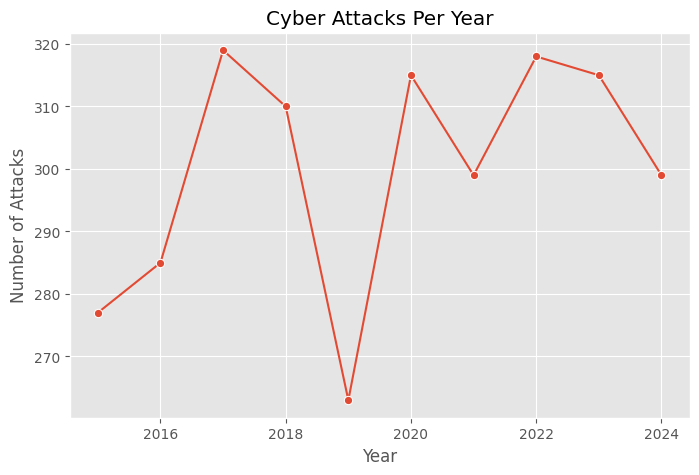

In [ ]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=attacks_per_year,
    x="year",
    y="Number of Attacks",
    marker="o"
)

plt.title("Cyber Attacks Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

plt.show()

### Insight

- The line chart shows the trend in the number of cyber attacks over the years.
- The highest number of attacks was recorded in 2017.
- The lowest number of attacks was recorded in 2019.

In [ ]:
country_attacks = global_threats["country"].value_counts().reset_index()

country_attacks.columns = ["Country", "Attack Count"]

country_attacks

,Country,Attack Count
0,Uk,321
1,Brazil,310
2,India,308
3,Japan,305
4,France,305
5,Australia,297
6,Russia,295
7,Germany,291
8,Usa,287
9,China,281


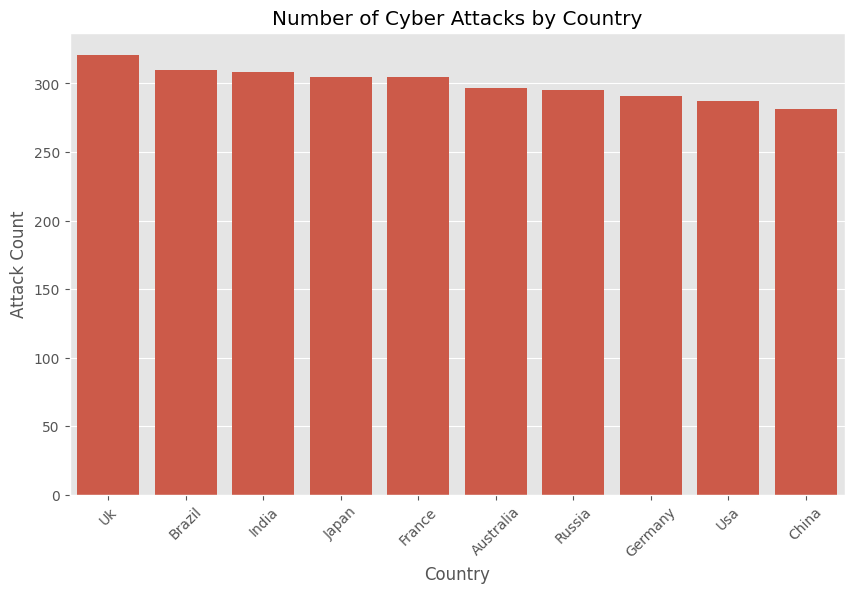

In [ ]:
# Bar Chart

plt.figure(figsize=(10,6))

sns.barplot(
    data=country_attacks,
    x="Country",
    y="Attack Count"
)

plt.title("Number of Cyber Attacks by Country")
plt.xlabel("Country")
plt.ylabel("Attack Count")
plt.xticks(rotation=45)

plt.show()

### Insight

- The bar chart shows the distribution of cyber attacks across different countries.
- The country with the highest number of attacks is UK.
- The country with the lowest number of attacks is China.

In [ ]:
attack_types = global_threats["attack_type"].value_counts().reset_index()

attack_types.columns = ["Attack Type", "Count"]

attack_types

,Attack Type,Count
0,Ddos,531
1,Phishing,529
2,Sql Injection,503
3,Ransomware,493
4,Malware,485
5,Man-In-The-Middle,459


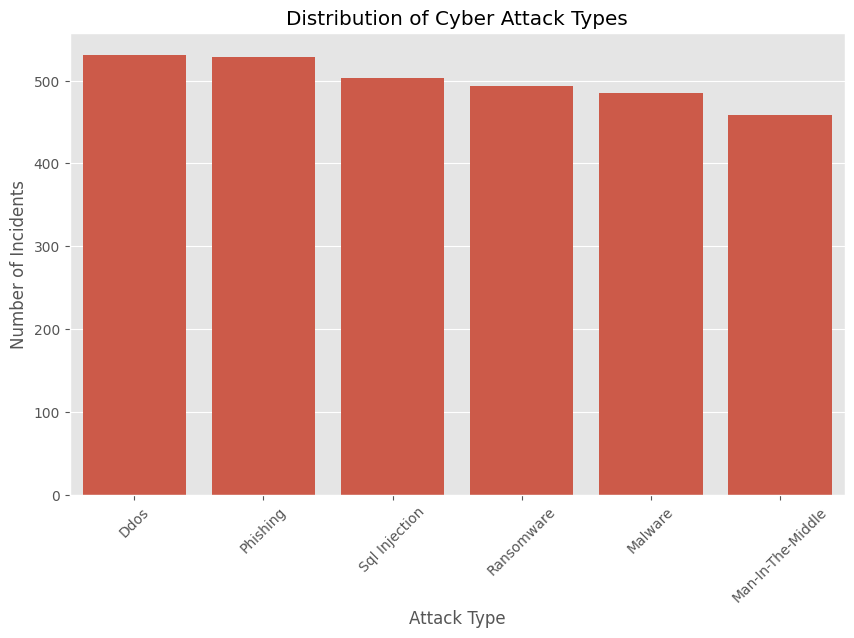

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=attack_types,
    x="Attack Type",
    y="Count"
)

plt.title("Distribution of Cyber Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)

plt.show()

### Insight

- The bar chart shows the frequency of different cyber attack types in the dataset.
- The most frequently occurring attack type is Ddos.
- The least frequently occurring attack type is Man In The Middle.
- This distribution helps identify which attack types are most prevalent and should receive greater attention in cybersecurity planning and mitigation efforts.

In [ ]:
industry_loss = (
    global_threats.groupby("target_industry")["financial_loss_in_million_"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

industry_loss

,target_industry,financial_loss_in_million_
0,Government,52.618685
1,It,51.903410
2,Banking,51.173910
3,Telecommunications,50.766973
4,Retail,49.928014
5,Healthcare,49.047296
6,Education,47.903174


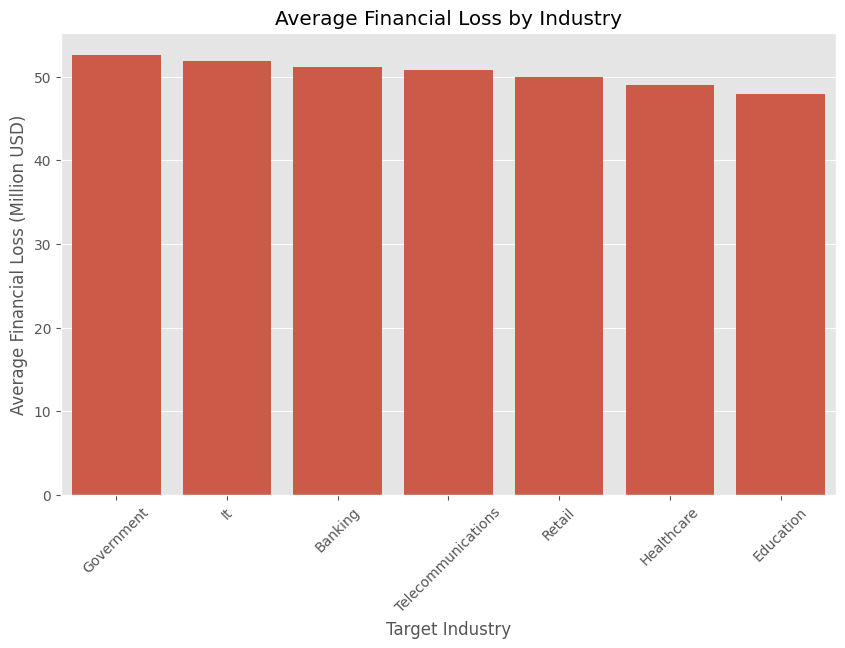

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=industry_loss,
    x="target_industry",
    y="financial_loss_in_million_"
)

plt.title("Average Financial Loss by Industry")
plt.xlabel("Target Industry")
plt.ylabel("Average Financial Loss (Million USD)")
plt.xticks(rotation=45)

plt.show()

### Insight

- The bar chart compares the average financial loss across different industries.
- The industry with the highest average financial loss is Government.
- The industry with the lowest average financial loss is Education.
- The results indicate that some industries experience significantly greater financial impacts from cyber attacks, highlighting the need for stronger cybersecurity measures in those sectors.

In [ ]:
attack_source = (
    global_threats.groupby("attack_source")
    .size()
    .reset_index(name="Count")
)
attack_source

,attack_source,Count
0,Hacker Group,686
1,Insider,752
2,Nation-State,794
3,Unknown,768


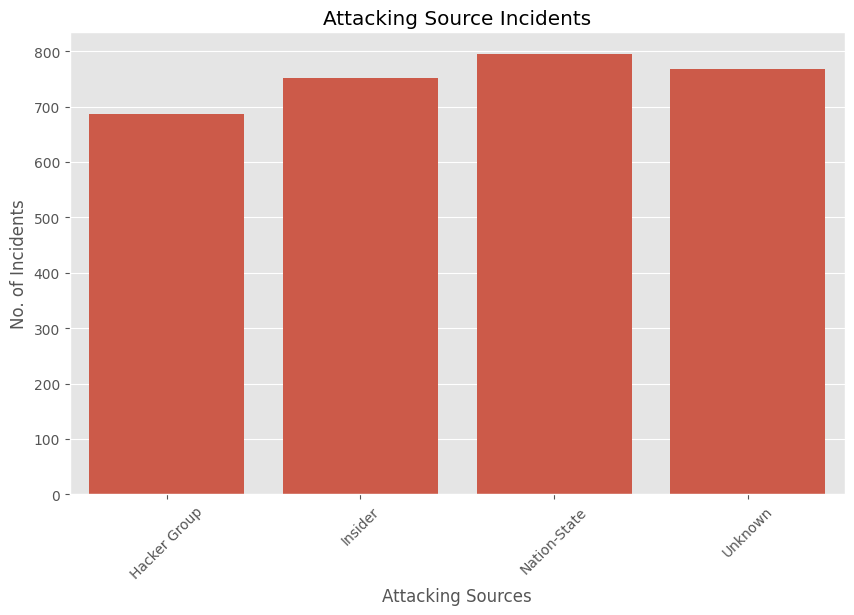

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=attack_source,
    x="attack_source",
    y="Count"
)

plt.title("Attacking Source Incidents")
plt.xlabel("Attacking Sources")
plt.ylabel("No. of Incidents")
plt.xticks(rotation=45)

plt.show()

In [ ]:
defense = global_threats["defense_mechanism_used"].value_counts()
defense

,count
defense_mechanism_used,
Antivirus,628
Vpn,612
Encryption,592
Firewall,585
Ai-Based Detection,583


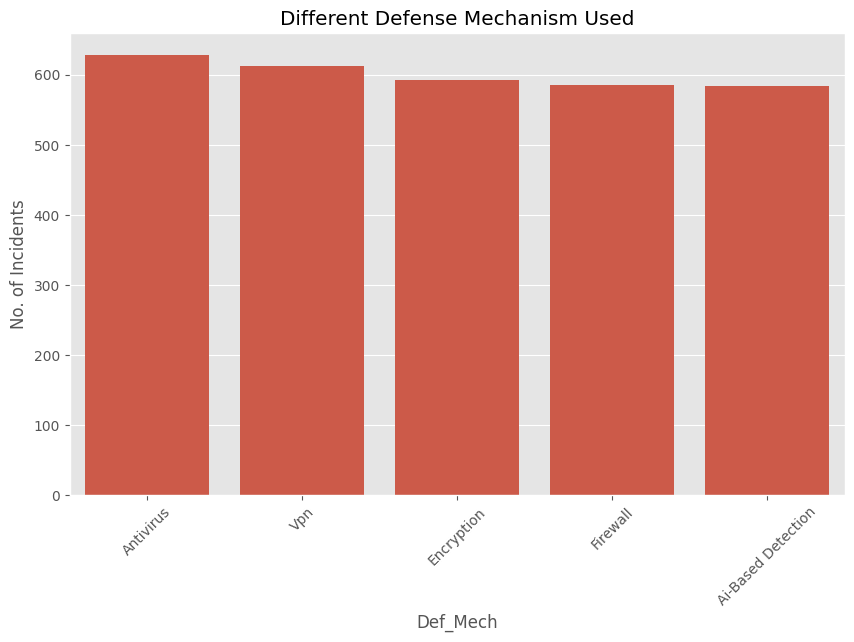

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=defense.reset_index(),
    x="defense_mechanism_used",
    y="count"
)

plt.title("Different Defense Mechanism Used")
plt.xlabel("Def_Mech")
plt.ylabel("No. of Incidents")
plt.xticks(rotation=45)

plt.show()

In [ ]:
global_threats["incident_resolution_time_in_hours"].describe()

,incident_resolution_time_in_hours
count,3000.000000
mean,36.476000
std,20.570768
min,1.000000
25%,19.000000
50%,37.000000
75%,55.000000
max,72.000000


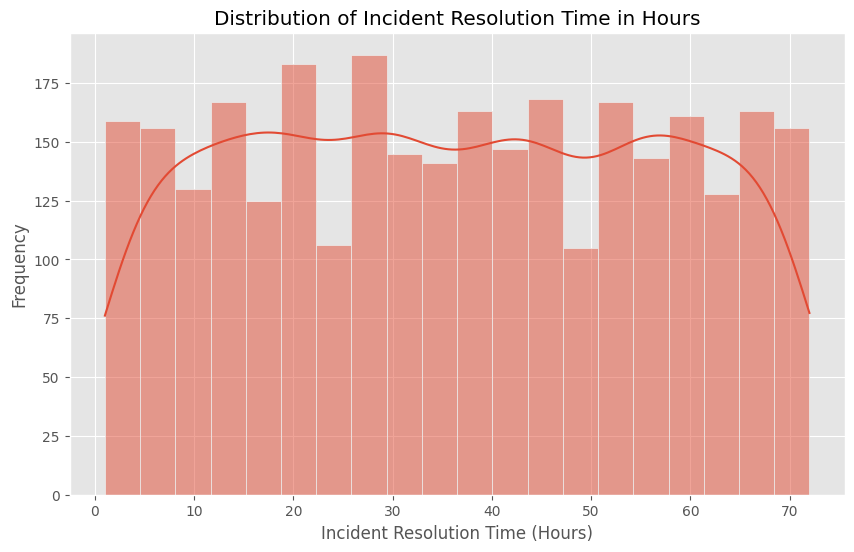

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=global_threats,
    x="incident_resolution_time_in_hours",
    bins=20, # You can adjust the number of bins as needed
    kde=True # Adds a kernel density estimate curve
)
plt.title("Distribution of Incident Resolution Time in Hours")
plt.xlabel("Incident Resolution Time (Hours)")
plt.ylabel("Frequency")

plt.savefig(
    "/content/Cyber-Attach-Visualisation/resolution_time_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
corr = global_threats.corr(numeric_only=True)
corr

,year,financial_loss_in_million_,number_of_affected_users,incident_resolution_time_in_hours
year,1.000000,0.010581,0.002317,-0.004982
financial_loss_in_million_,0.010581,1.000000,0.001787,-0.012671
number_of_affected_users,0.002317,0.001787,1.000000,0.005893
incident_resolution_time_in_hours,-0.004982,-0.012671,0.005893,1.000000


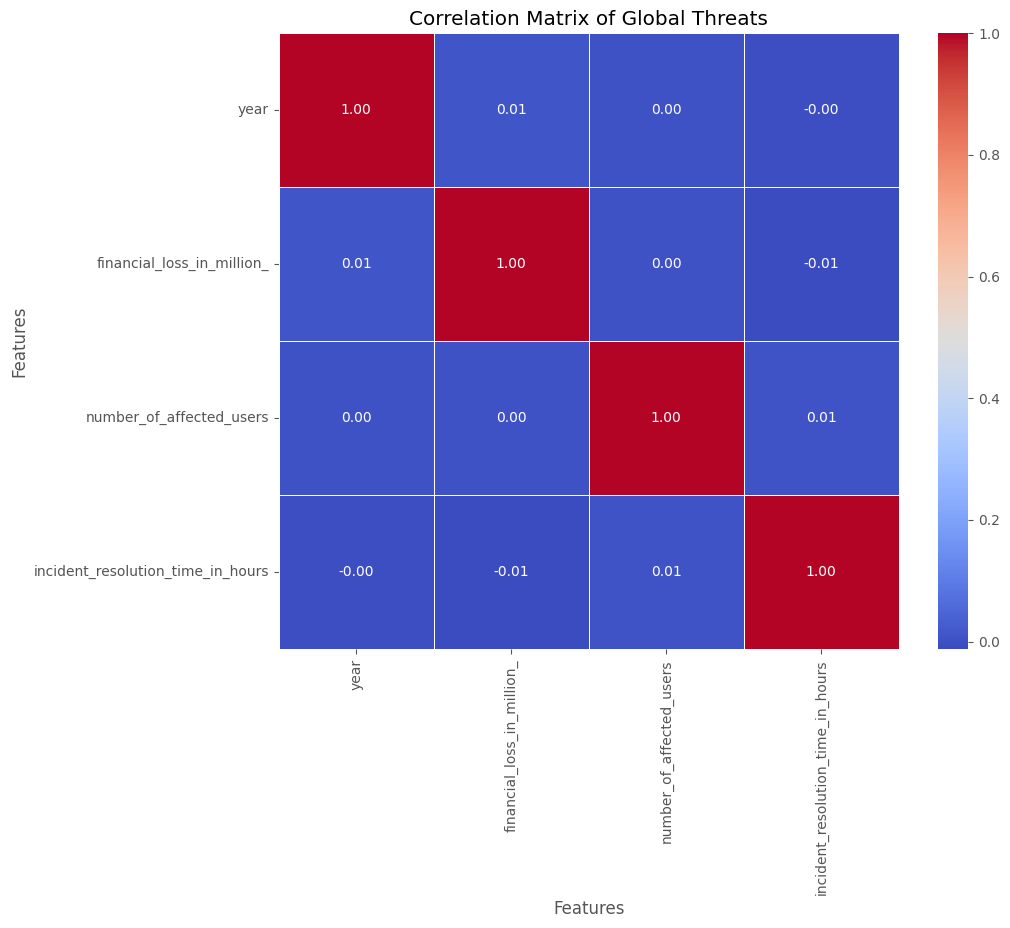

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True, # Show correlation values on the heatmap
    cmap='coolwarm', # Color map for positive and negative correlations
    fmt=".2f", # Format annotation values to two decimal places
    linewidths=.5 # Add lines between cells
)
plt.title("Correlation Matrix of Global Threats")
plt.xlabel("Features")
plt.ylabel("Features")

plt.savefig(
    "/content/Cyber-Attach-Visualisation/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### EDA for CFR Incidents, Vulnerabilities, and MalMem datasets

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
cfr_incidents = pd.read_csv('/content/Cyber-Attach-Visualisation/data/processed/cfr_incidents_clean.csv')
vulnerabilities = pd.read_csv('/content/Cyber-Attach-Visualisation/data/processed/vulnerabilities_clean.csv')
malmem = pd.read_csv('/content/Cyber-Attach-Visualisation/data/processed/malmem_clean.csv')

# 1. CFR Incidents: Incidents by Category
plt.figure(figsize=(10, 6))
sns.countplot(data=cfr_incidents, y='category', order=cfr_incidents['category'].value_counts().index)
plt.title('CFR Incidents by Category')
plt.savefig('/content/Cyber-Attach-Visualisation/cfr_category_dist.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Vulnerabilities: Severity Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=vulnerabilities, x='severity', order=['Low', 'Medium', 'High', 'Critical'] if 'severity' in vulnerabilities.columns else None)
plt.title('Distribution of Vulnerability Severities')
plt.savefig('/content/Cyber-Attach-Visualisation/vulnerability_severity.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. MalMem: Malware Family Distribution
plt.figure(figsize=(10, 6))
malmem['family'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Malware Families (MalMem)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig('/content/Cyber-Attach-Visualisation/malmem_family_dist.png', dpi=300, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/Cyber-Attach-Visualisation/data/processed/vulnerabilities_clean.csv'

In [ ]:
# First 5 rows
cfr_incidents.head()

In [ ]:
# Information about the dataset
cfr_incidents.info()

In [ ]:
# Statistical summary
cfr_incidents.describe(include="all")

In [ ]:
# Missing values
cfr_incidents.isnull().sum()

In [ ]:
cfr_incidents["date"] = pd.to_datetime(cfr_incidents["date"], errors="coerce")

cfr_incidents["year"] = cfr_incidents["year"].fillna(
    cfr_incidents["date"].dt.year
)

In [ ]:
cfr_incidents["year"].isnull().sum()

### Detailed EDA: CFR Incidents
We will examine the distribution of 'sponsor' (the actor behind the incident) and the 'type' of operations.

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=cfr_incidents, y='sponsor', order=cfr_incidents['sponsor'].value_counts().head(10).index)
plt.title('Top 10 Incident Sponsors (CFR)')
plt.savefig('/content/Cyber-Attach-Visualisation/cfr_top_sponsors.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
cfr_incidents.groupby('year').size().plot(kind='line', marker='o', color='teal')
plt.title('CFR Incidents Over Time')
plt.ylabel('Number of Incidents')
plt.savefig('/content/Cyber-Attach-Visualisation/cfr_incidents_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

### Detailed EDA: Security Vulnerabilities
Let's look at the most frequent vulnerability titles or common keywords and how severity relates to the year.

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=vulnerabilities, x='severity', y='year', order=['Low', 'Medium', 'High', 'Critical'])
plt.title('Vulnerability Severity Trends over Years')
plt.savefig('/content/Cyber-Attach-Visualisation/vulnerability_severity_trends.png', dpi=300, bbox_inches='tight')//
plt.show()

### Detailed EDA: MalMem Dataset
Since MalMem contains many technical memory features, we will look at the correlation between key memory metrics (like `pslist.nproc` and `handle.nhandles`) and the malware `category`.

In [ ]:
# Selecting a subset of numeric columns using corrected names (dots removed)
malmem_subset = malmem[['pslistnproc', 'handlesnhandles', 'dlllistndlls', 'malfindninjections', 'category']]

# Grouping by category to see mean values of memory artifacts
malmem_summary = malmem_subset.groupby('category').mean()
display(malmem_summary)

plt.figure(figsize=(10, 6))
sns.heatmap(malmem_summary, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Mean Memory Artifacts by Malware Category')
plt.savefig('/content/Cyber-Attach-Visualisation/malmem_category_artifacts.png', dpi=300, bbox_inches='tight')
plt.show()

### Detailed EDA: Attack Signatures
We will examine the distribution of attack categories and their recorded severity levels from the `attack_signatures` dataset.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the processed attack signatures data
attack_sigs = pd.read_csv('/content/Cyber-Attach-Visualisation/data/processed/attack_signatures_clean.csv')

# Fix: Use lowercase column names as they appear in the cleaned data
plt.figure(figsize=(12, 6))
sns.countplot(data=attack_sigs, x='attack_type', hue='severity_level')

plt.title('Attack Type Distribution by Severity (Signatures)')
plt.xticks(rotation=45)
plt.savefig('/content/Cyber-Attach-Visualisation/attack_sigs_severity.png', dpi=300, bbox_inches='tight')
plt.show()

### EDA Summary
I have completed the detailed Exploratory Data Analysis for all processed datasets:
- **Global Threats**: Correlation heatmap and resolution time distribution.
- **CFR Incidents**: Top sponsors and incident timeline.
- **Vulnerabilities**: Severity trends over time.
- **MalMem**: Mean memory artifacts by malware category.
- **Attack Signatures**: Severity distribution per attack type.

All visualizations have been saved as PNG files in `/content/Cyber-Attach-Visualisation/`.

### Detailed EDA: Attack Signatures
Finally, let's examine the distribution of 'Attack Type' and 'Severity Level' within the attack signatures dataset.

In [ ]:
# Load and fix the Attack Signatures analysis
attack_sigs = pd.read_csv('/content/Cyber-Attach-Visualisation/data/processed/attack_signatures_clean.csv')

# Inspect columns to find best matches for 'Attack Type' and 'Severity Level'
print('Available columns:', attack_sigs.columns.tolist())

# Dynamically select columns based on probable naming conventions
x_col = next((c for c in attack_sigs.columns if 'attack' in c.lower() and 'type' in c.lower()), attack_sigs.columns[0])
hue_col = next((c for c in attack_sigs.columns if 'severity' in c.lower()), attack_sigs.columns[1])

plt.figure(figsize=(12, 6))
sns.countplot(data=attack_sigs, x=x_col, hue=hue_col)
plt.title(f'Attack Distribution: {x_col} by {hue_col}')
plt.xticks(rotation=45)
plt.savefig('/content/Cyber-Attach-Visualisation/attack_sigs_severity.png', dpi=300, bbox_inches='tight')
plt.show()

### Summary of EDA Results
We have successfully performed detailed Exploratory Data Analysis on all five datasets:
1. **Global Threats**: Trends over time, country-wise impacts, and financial loss analysis.
2. **CFR Incidents**: Sponsor identification and incident timelines.
3. **Security Vulnerabilities**: Severity distribution and trends over years.
4. **MalMem**: Malware family counts and memory artifact profiling.
5. **Attack Signatures**: Attack types and severity level mapping.

All plots have been saved as high-resolution PNG files in `/content/Cyber-Attach-Visualisation/`.